# Tutorial 4: Attention and Alignment

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/byu-matrix-lab/torchlingo/blob/main/docs/docs/tutorials/04-attention-and-alignment.ipynb)

Attention is the single most important idea in modern NMT, and it is usually
taught as a formula. Here you will *measure* it instead.

By the end you will have:

1. Seen the information bottleneck in the code, as a discarded variable
2. Trained the same model with and without attention, and compared them
3. Checked whether attention learned the **correct** alignment — on a task where
   we know the right answer in advance
4. Read an alignment heatmap
5. Seen why the Transformer's self-attention is the same operation

**⚡ Running in Google Colab?** Uncomment the `%pip install torchlingo` cell below.

In [1]:
# Install TorchLingo (uncomment in Google Colab)
# %pip install torchlingo

import random

import matplotlib.pyplot as plt
import torch
from torch import optim
from torch.utils.data import DataLoader, TensorDataset

from torchlingo.config import get_default_config
from torchlingo.models import SimpleSeq2SeqLSTM
from torchlingo.training import train_model
from torchlingo.visualization import format_attention, plot_attention

CFG = get_default_config()
torch.manual_seed(0)

print(f"PyTorch {torch.__version__}")

PyTorch 2.13.0


## Part 1: The bottleneck, as a discarded variable

A plain LSTM encoder-decoder reads the whole source sentence and hands the
decoder **one fixed-size vector**. Every source token is encoded and then thrown
away.

That is not a metaphor. It is visible in the code. `encode_source` returns three
things, and a model without attention uses only the second:

```python
enc_out, hidden, src_pad_mask = model.encode_source(src)
#  ^^^^^^^ one vector per source token — discarded without attention
#           ^^^^^^ a single vector for the whole sentence — all the decoder gets
```

Let's confirm the shapes.

In [2]:
plain = SimpleSeq2SeqLSTM(
    src_vocab_size=30, tgt_vocab_size=30,
    emb_dim=64, hidden_dim=64, num_layers=1, dropout=0.0,
    attention=False,          # the default
)

src = torch.randint(4, 30, (1, 7))       # one 7-token source sentence
enc_out, (h, c) = plain.encode_source(src)[:2]

print(f"enc_out : {tuple(enc_out.shape)}   <- one 64-dim vector per source token")
print(f"hidden  : {tuple(h.shape)}   <- ONE vector for the whole sentence")
print()
print(f"Without attention, {enc_out.shape[1]} vectors are computed and "
      f"{enc_out.shape[1] - 1} are thrown away.")
print(f"Everything the decoder knows about the source must fit in {h.numel()} numbers,")
print("no matter how long the sentence is. That is the bottleneck.")

enc_out : (1, 7, 64)   <- one 64-dim vector per source token
hidden  : (1, 1, 64)   <- ONE vector for the whole sentence

Without attention, 7 vectors are computed and 6 are thrown away.
Everything the decoder knows about the source must fit in 64 numbers,
no matter how long the sentence is. That is the bottleneck.


## Part 2: A task where we know the correct alignment

To ask *"did attention learn the right thing?"* we need to know what the right
thing is. Real corpora don't come with alignments, so we build a task that does.

**The task:** translate each word through a fixed bilingual lexicon, then
**reverse** the sentence.

```
source:  the cat sees a small bird
target:  pajaro pequeno un ve gato el
```

Two reasons this is the right toy problem:

- **Reversal forces long-range dependency.** The first target word comes from the
  *last* source word, which is exactly what a single fixed-size vector handles
  badly.
- **The correct alignment is known**: an anti-diagonal. So "did attention work?"
  becomes a number we can compute, not a picture we squint at.

In [3]:
LEXICON = {
    "the": "el", "a": "un", "cat": "gato", "dog": "perro", "bird": "pajaro",
    "fish": "pez", "child": "nino", "woman": "mujer", "man": "hombre",
    "sees": "ve", "eats": "come", "finds": "halla", "wants": "quiere",
    "small": "pequeno", "big": "grande", "red": "rojo", "old": "viejo",
}
MIN_WORDS, MAX_WORDS = 3, 6

specials = [CFG.pad_token, CFG.unk_token, CFG.sos_token, CFG.eos_token]
src_itos = specials + sorted(LEXICON)
tgt_itos = specials + sorted(LEXICON.values())
src_stoi = {t: i for i, t in enumerate(src_itos)}
tgt_stoi = {t: i for i, t in enumerate(tgt_itos)}


def make_pair(rng):
    """Sample one (source, target) id pair: translated word-for-word, reversed."""
    words = [rng.choice(list(LEXICON)) for _ in range(rng.randint(MIN_WORDS, MAX_WORDS))]
    source = [CFG.sos_idx] + [src_stoi[w] for w in words] + [CFG.eos_idx]
    target = ([CFG.sos_idx]
              + [tgt_stoi[LEXICON[w]] for w in reversed(words)]
              + [CFG.eos_idx])
    return source, target


demo_rng = random.Random(1)
for _ in range(3):
    s, t = make_pair(demo_rng)
    print(" ".join(src_itos[i] for i in s[1:-1]))
    print("   ->", " ".join(tgt_itos[i] for i in t[1:-1]))

cat man dog red
   -> rojo perro hombre gato
red wants child dog red the
   -> el rojo perro nino quiere rojo
small the big man woman dog
   -> perro mujer hombre grande el pequeno


In [4]:
def make_dataset(n, rng):
    """Build a padded TensorDataset of n sampled pairs."""
    pairs = [make_pair(rng) for _ in range(n)]
    width = MAX_WORDS + 2

    def pad(ids):
        return ids + [CFG.pad_idx] * (width - len(ids))

    return TensorDataset(
        torch.tensor([pad(s) for s, _ in pairs]),
        torch.tensor([pad(t) for _, t in pairs]),
    )


rng = random.Random(0)
train_loader = DataLoader(make_dataset(3000, rng), batch_size=64, shuffle=True)
val_loader = DataLoader(make_dataset(300, rng), batch_size=64)

print(f"{len(train_loader.dataset)} training pairs, "
      f"{len(val_loader.dataset)} validation pairs")

3000 training pairs, 300 validation pairs


## Part 3: The ablation

Same data, same size, same seed, same number of epochs. **One flag differs.**

That is why attention is off by default in TorchLingo: it keeps the classic
bottlenecked model as the baseline you compare against, so the comparison is one
visible line rather than hidden history.

In [5]:
def train_one(label, attention, attn_type="dot"):
    """Train one configuration and return the model and its final val loss."""
    torch.manual_seed(0)
    model = SimpleSeq2SeqLSTM(
        src_vocab_size=len(src_stoi), tgt_vocab_size=len(tgt_stoi),
        emb_dim=64, hidden_dim=64, num_layers=1, dropout=0.0,
        attention=attention, attn_type=attn_type,
    )
    result = train_model(
        model, train_loader, val_loader, num_epochs=16,
        optimizer=optim.Adam(model.parameters(), lr=5e-3),
    )
    return model, result.val_losses[-1]


no_attn, no_attn_loss = train_one("no attention", attention=False)
dot_attn, dot_attn_loss = train_one("dot attention", attention=True)

print()
print(f"{'configuration':20s} {'val loss':>10s}")
print("-" * 32)
print(f"{'no attention':20s} {no_attn_loss:10.4f}")
print(f"{'dot (Luong)':20s} {dot_attn_loss:10.4f}")

Epoch 1/16 | Train: 3.0493 | Val: 3.0408


Epoch 2/16 | Train: 3.0293 | Val: 3.0096


Epoch 3/16 | Train: 2.9817 | Val: 2.9359


Epoch 4/16 | Train: 2.8408 | Val: 2.7111


Epoch 5/16 | Train: 2.5843 | Val: 2.4335


...

Epoch 12/16 | Train: 0.6399 | Val: 0.6413


Epoch 13/16 | Train: 0.6335 | Val: 0.6352


Epoch 14/16 | Train: 0.6285 | Val: 0.6312


Epoch 15/16 | Train: 0.6244 | Val: 0.6264


Epoch 16/16 | Train: 0.6210 | Val: 0.6231

configuration          val loss
--------------------------------
no attention             0.7807
dot (Luong)              0.6231


The gap is real, but a loss number alone doesn't tell you *why* the model got
better. It could have memorized the lexicon and guessed at the ordering.

So let's ask the sharper question.

## Part 4: Did it learn the **right** alignment?

Because the target is the reversed source, the token predicted at decoder row
`j` of a length-`n` sentence comes from source index `n - j` (index 0 holds
`<sos>`). A model that has genuinely learned the task should put its attention
peak exactly there.

That gives us **alignment accuracy**: how often the argmax lands on the truly
aligned source word. Chance is roughly `1 / src_len`.

In [6]:
def alignment_accuracy(model, n_samples=200):
    """Fraction of decoder positions whose peak attention is on the right word."""
    rng = random.Random(99)
    model.eval()
    hits = total = 0
    for _ in range(n_samples):
        source, target = make_pair(rng)
        n_words = len(source) - 2
        with torch.no_grad():
            _logits, weights = model(
                torch.tensor([source]), torch.tensor([target[:-1]]),
                return_attention=True,
            )
        peaks = weights[0].argmax(dim=-1)
        for row in range(n_words):
            total += 1
            hits += int(peaks[row].item() == n_words - row)
    return hits / max(total, 1)


accuracy = alignment_accuracy(dot_attn)
chance = 1 / ((MIN_WORDS + MAX_WORDS) / 2 + 2)

print(f"alignment accuracy : {accuracy:.1%}")
print(f"chance             : {chance:.1%}")

alignment accuracy : 97.7%
chance             : 15.4%


## Part 5: Look at it

Attention weights are the most directly inspectable quantity in an NMT model.
Each row is a probability distribution over source positions: *while producing
this target token, here is how much I looked at each source word.*

`format_attention` renders that as text — useful over SSH, in logs, and in
doctests. Rows are target tokens, columns are source tokens, shading runs
`·` `░` `▒` `▓` `█`.

In [7]:
sample_rng = random.Random(7)
source, target = make_pair(sample_rng)
src_tokens = [src_itos[i] for i in source]
tgt_tokens = [tgt_itos[i] for i in target[:-1]]

with torch.no_grad():
    _logits, weights = dot_attn(
        torch.tensor([source]), torch.tensor([target[:-1]]), return_attention=True
    )

print("source:", " ".join(src_tokens[1:-1]))
print("target:", " ".join(tgt_tokens[1:]))
print()
print(format_attention(weights, src_tokens, tgt_tokens))

source: bird wants a cat dog
target: perro gato un quiere pajaro

       <sos>  bird wants     a   cat   dog <eos>
<sos>    ···   ···   ···   ···   ···   ▓▓▓   ░░░
perro    ···   ···   ···   ···   ███   ···   ···
gato     ···   ···   ···   ███   ···   ···   ···
un       ···   ···   ███   ···   ···   ···   ···
quiere   ···   ███   ···   ···   ···   ···   ···
pajaro   ███   ···   ···   ···   ···   ···   ···


**Read the anti-diagonal.** To emit the first target word the decoder looks at
the *last* source word, and it walks backwards from there — which is exactly the
task definition, learned from examples alone.

Each row is offset by one from the token naming it, because row `n` is the state
that *predicts* token `n + 1`.

The same matrix as a heatmap:

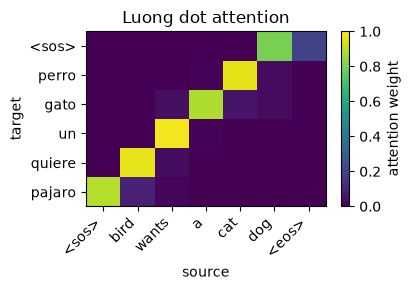

In [8]:
plot_attention(weights, src_tokens, tgt_tokens, title="Luong dot attention")
plt.show()

## Part 6: Bahdanau or Luong?

Both scorers do the same three things — score each source position, softmax into
weights, average the encoder outputs. They differ only in how the score is
computed:

| `attn_type` | Score | Paper | Parameters |
| --- | --- | --- | --- |
| `"additive"` | `v · tanh(W_dec h_t + W_enc h_s)` | Bahdanau et al., 2014 | three matrices |
| `"dot"` | `h_t · h_s` | Luong et al., 2015 | **none** |

Bahdanau *learns* how to compare decoder and encoder states. Luong noticed that
if the two already live in the same space, an inner product will do.

In [9]:
additive_attn, additive_loss = train_one(
    "additive", attention=True, attn_type="additive"
)

print()
print(f"{'configuration':20s} {'val loss':>10s} {'alignment':>12s}")
print("-" * 45)
print(f"{'no attention':20s} {no_attn_loss:10.4f} {'n/a':>12s}")
print(f"{'dot (Luong)':20s} {dot_attn_loss:10.4f} {accuracy:11.1%}")
print(f"{'additive (Bahdanau)':20s} {additive_loss:10.4f} "
      f"{alignment_accuracy(additive_attn):11.1%}")

Epoch 1/16 | Train: 3.0406 | Val: 3.0343


Epoch 2/16 | Train: 3.0172 | Val: 2.9949


Epoch 3/16 | Train: 2.9398 | Val: 2.8539


Epoch 4/16 | Train: 2.7379 | Val: 2.6218


Epoch 5/16 | Train: 2.4428 | Val: 2.2423


...

Epoch 12/16 | Train: 0.6405 | Val: 0.6347


Epoch 13/16 | Train: 0.6303 | Val: 0.6270


Epoch 14/16 | Train: 0.6238 | Val: 0.6218


Epoch 15/16 | Train: 0.6194 | Val: 0.6179


Epoch 16/16 | Train: 0.6161 | Val: 0.6149

configuration          val loss    alignment
---------------------------------------------
no attention             0.7807          n/a
dot (Luong)              0.6231       97.7%
additive (Bahdanau)      0.6149       84.5%


## Part 7: You have already seen the Transformer's mechanism

Take Luong's dot-product score, divide by `sqrt(d_k)` to keep the softmax out of
saturation at large dimensions, and run several copies in parallel. That is
Transformer attention.

```python
# What you just trained (torchlingo/models/attention.py)
scores = torch.bmm(dec_out, enc_out.transpose(1, 2))
weights = scores.softmax(dim=-1)
context = torch.bmm(weights, enc_out)
```

One more step gets you the rest of the way. In the decoder above, the queries
come from the target and the keys and values from the source — that is
**cross-attention**. Point the same operation at a single sequence, so it
attends to *itself*, and you have **self-attention**.

So the Transformer isn't a new mechanism. It is this one, scaled, run in
parallel heads, and applied in both configurations — which is why it can drop
the recurrence entirely.

## Next steps

- **Real data.** `data/example.tsv` ships with the repo: 73,083 English→Spanish
  sentence pairs. The code above transfers directly; real alignments are
  messier than an anti-diagonal, and that is the point — real translation
  reorders, drops and merges words.
- **Decoding.** Both `greedy_decode` and `beam_search_decode` accept this model.
  See [Tutorial 3](03-inference-and-beamsearch.ipynb).
- **A measured ablation.** `python examples/attention_alignment.py` runs this
  comparison at larger scale and reports the whole table.
- **The mechanism itself.** [Attention reference](../reference/models/attention.md)
  walks through both scorers in about fifteen lines each.